# Árbol de decisión y Bosque aleatorio

Ing. Mayarling Martinez Flores

## Parte 1: Árbol de decisión(Decision Tree)

In [7]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

## from regulizacion import noise

In [9]:
mydata = load_iris()
x = mydata.data # data de entrada
y = mydata.target # data de salida

print(x.shape)
print(y.shape)

(150, 4)
(150,)


In [11]:
mydata.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [12]:
mydata.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [14]:
X_tv, X_test, y_tv, y_test = train_test_split(x, y, test_size=.2, shuffle=True, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=.25, shuffle=True, random_state=1)

print('Tamaño del conjunto de entrenamiento:', X_train.shape)
print('Tamaño del conjunto de validación:', X_val.shape)
print('Tamaño del conjunto de prueba', X_test.shape)

Tamaño del conjunto de entrenamiento: (90, 4)
Tamaño del conjunto de validación: (30, 4)
Tamaño del conjunto de prueba (30, 4)


{'whiskers': [<matplotlib.lines.Line2D at 0x2105eb1e900>,
 'caps': [<matplotlib.lines.Line2D at 0x2105eb1eba0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2105eb1e7b0>,
 'medians': [<matplotlib.lines.Line2D at 0x2105eb1ee40>,
 'fliers': [<matplotlib.lines.Line2D at 0x2105eb1ef90>,
 'means': []}

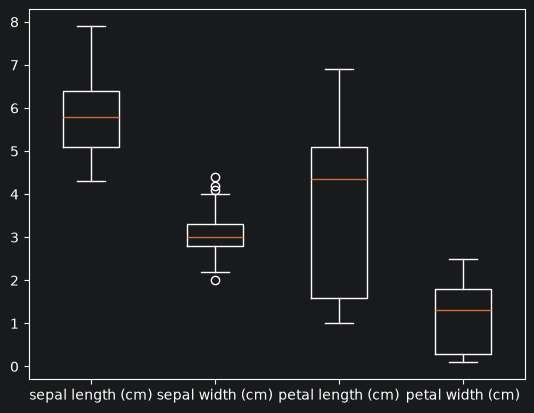

In [17]:
plt.boxplot(x, tick_labels=mydata.feature_names)

In [18]:
## Generamos un árbol de decisión

modelDT = DecisionTreeClassifier() # INicializamos con los hiperparametros determinados
clf = modelDT.fit(X_train, y_train) # entrenamos el modleo con los datos de entrenamiento

# observamos el desempeño
print('Exactitud en el conjunto de entrenamiento:', clf.score(X_train, y_train))

Exactitud en el conjunto de entrenamiento: 1.0


In [19]:
predicciones = clf.predict(X_val)
print('exactitud en el conjunto de vaidacion:', clf.score(X_val, y_val))

exactitud en el conjunto de vaidacion: 0.9666666666666667


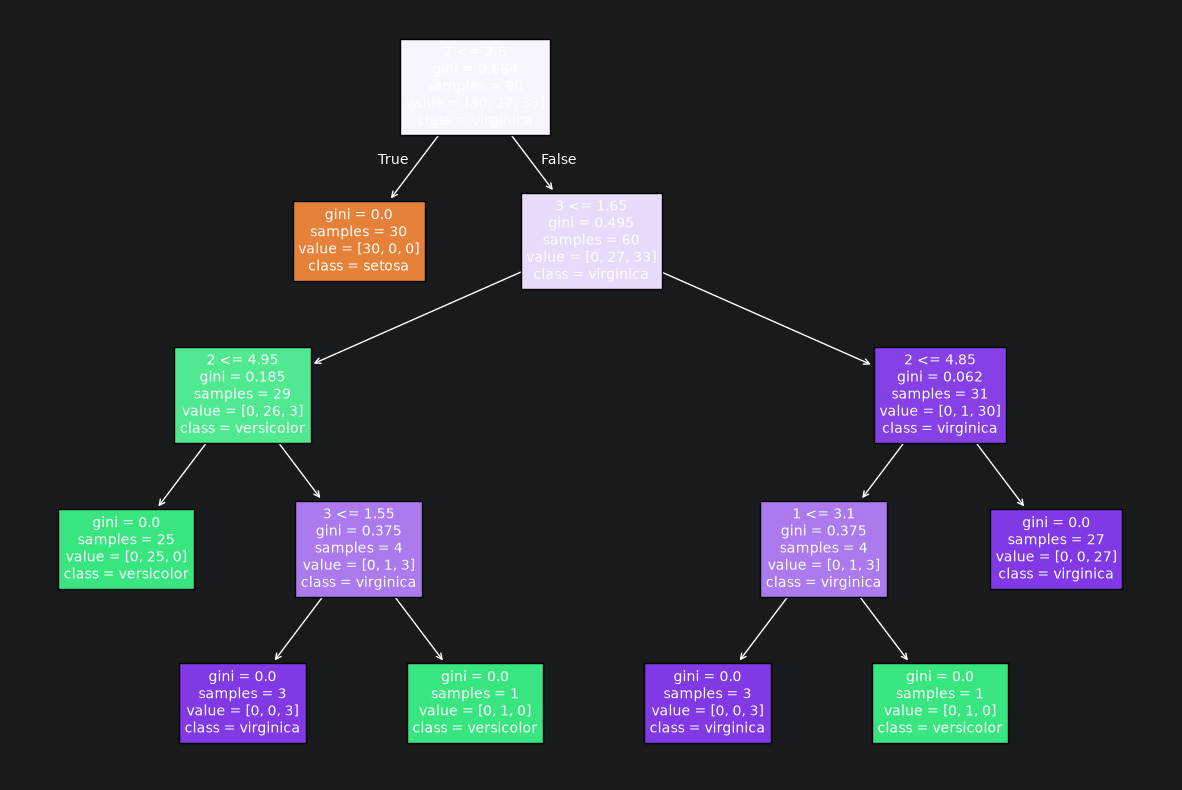

In [20]:
# pra realizar un grafo de decision Tree
from sklearn import tree
# Para realizar un grafo de Decision Tree
from sklearn import tree
# 1. Configurar el tamaño de la imagen
plt.figure(figsize=(15, 10))
# 2. Dibujar el árbol directamente
tree.plot_tree(decision_tree=clf,
               max_depth=None,
               feature_names=list(pd.DataFrame(X_train).columns.astype(str)),
               class_names=[str(c) for c in mydata.target_names],
               filled=True,
               proportion=False,
               fontsize=10)
# 3. Mostrar la imagen en Jupyter
plt.show()

## Parte 2 = Random Forest (Bosque aleatorio)

In [21]:
import sklearn.datasets

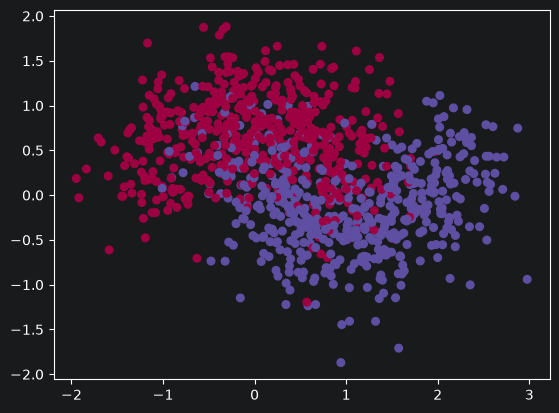

In [27]:
N = 1000
noisy_data = sklearn.datasets.make_moons(n_samples=N, noise=0.4, random_state=17)
x, y = noisy_data
plt.scatter(x[:, 0], x[:, 1], c=y, s=30, cmap=plt.cm.Spectral)  # graficamos los datos

In [29]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(x, y, test_size=.4, shuffle=True, random_state=17)

mimodelo = RandomForestClassifier()

clf = mimodelo.fit(Xtrain,Ytrain)

results = clf.predict(Xtest)

confusion_matrix(Ytest, results)

array([[165,  37],
       [ 33, 165]])

In [30]:
clf.score(Xtest, Ytest)

0.825

In [31]:
clf.feature_importances_

array([0.45388656, 0.54611344])

<BarContainer object of 2 artists>

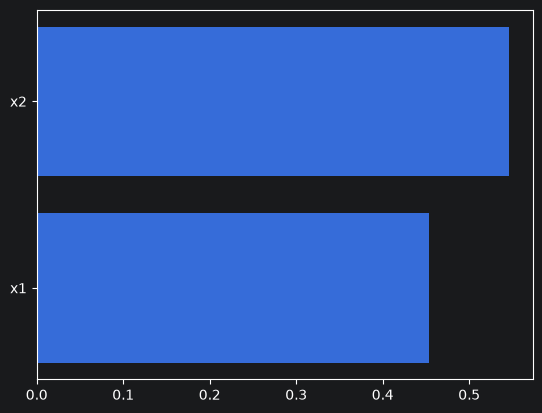

In [32]:
plt.barh(['x1', 'x2'], width=clf.feature_importances_)

In [34]:
## Algunos de lo hiperparámetros del clasificador bosque aleatorio:
mimodelo2 = RandomForestClassifier(n_estimators=10,  # número de árboles en el Forest y después promedia por votación.
                                   criterion='gini',   # métrica para determinar las ramas. También puede ser: 'entropy', para la GananciaDeInformación (IG).
                                   max_depth=2, # Depth=k : máximo 2^k líneas/ramas.
                                   min_samples_split = 6,  # mínimo de puntos muestrales requeridos en un nodo para hacer la ramificación. Puede ser fracción de 0 a 1.
                                   min_samples_leaf = 4,  # mínimo de puntos muestrales que deben quedar en cada nueva ramificación (hojas). Puede ser fracción de 0 a 1.
                                   #max_features= 'auto',   # número de características (features) que se consideran en cada ramificación: auto=sqrt(n_features).
                                   max_leaf_nodes=16,  # solo nos quedamos con las mejores k hojas.
                                   bootstrap=True,  # Cada Árbol se muestrea seleccionando la cantidad de datos del conjunto de entrenamiento, pero con reemplazo. False:los datos usados en cada árbol simpre es el mismo, el Train-set.
                                   oob_score=True,  # en caso de utilizar Out-of-bag samples.
                                   verbose=0,     # tipo de despliega de información durante el entrenamiento.
                                   n_jobs=-1,    # total de hilos a usar en las rutinas paralelizables: "-1" :usar todos los posibles.
                                   max_samples=None,   # Cuando se usa Boostrap, es el total de datos de Xtrain a usar en cada árbol. "None" usará Xtrain[0].
                                   random_state=19)

In [ ]:
clf2 = mimodelo2.fit(Xtrain,Ytrain)
clf2.score(Xtest,Ytest)